# Engineering features for Wafer Maps

In this notebook, we will do the following:
- Experiment with various engineered features on the Wafer Map Dataset
    - 4 Baseline Features
    - 58 Features from Wu et al.
- Explore classical ML models to classify wafer defect patterns using engineered features

**Dataset name**: [WM-811K wafer map](https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map)
**Paper**: [Wafer Map Failure Pattern Recognition and Similarity Ranking for Large-Scale Data Sets](https://www.semanticscholar.org/paper/Wafer-Map-Failure-Pattern-Recognition-and-Ranking-Wu-Jang/a581566276f3b2242ec6544c185204a96f17db8a)

Authors: Sam Jafari & Purav Parab

In [1]:
# !pip install pandas kagglehub scikit-learn seaborn -q

In [2]:
# import kagglehub
# kagglehub.login()

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore', category=np.exceptions.VisibleDeprecationWarning)

## Dataset

In [4]:
print("Loading dataset...")
# file_path = "/root/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1/LSWMD.pkl"
file_path = "../data/LSWMD.pkl" # Change this to where the LSWMD.pkl is downloaded
df_original = pd.read_pickle(file_path)
print(f"Done. {len(df_original)} rows loaded.")

Loading dataset...
Done. 811457 rows loaded.


### Cleaning

In this section, we will do the following dataset cleaning steps to get our dataset ready

1. Rename "trianTestLabel" to "trainTestLabel"
2. Drop samples with unlabeled failureType
3. Drop samples with unlabeled trainTestLabel
4. Drop any null rows
5. Drop duplicates

1. Rename "trianTestLabel" to "trainTestLabel"

In [5]:
df_labeled = df_original.rename(columns={"trianTestLabel":"trainTestLabel"})

2. Drop samples with unlabeled failureType

In [6]:
# Convert failureType to strings
df_labeled["failureType_str"] = df_labeled["failureType"].astype(str)

# Drop samples where the failureType is unlabeled ([]]
df_labeled = df_labeled[df_labeled["failureType_str"] != "[]"].copy()

# Get counts for each unique value in labeled failureType
df_labeled["failureType_str"].value_counts()

failureType_str
[['none']]         147431
[['Edge-Ring']]      9680
[['Edge-Loc']]       5189
[['Center']]         4294
[['Loc']]            3593
[['Scratch']]        1193
[['Random']]          866
[['Donut']]           555
[['Near-full']]       149
Name: count, dtype: int64

3. Drop samples with unlabeled trainTestLabel

In [7]:
# Convert trainTestLabel to strings
df_labeled["trainTestLabel_str"] = df_labeled["trainTestLabel"].astype(str)

# Drop samples where the trainTestLabel is unlabeled ([]]
df_labeled = df_labeled[df_labeled["trainTestLabel_str"] != "[]"].copy()

# Get counts for each unique value in labeled trainTestLabel
df_labeled["trainTestLabel_str"].value_counts()

trainTestLabel_str
[['Test']]        118595
[['Training']]     54355
Name: count, dtype: int64

4. Drop any null rows

- 0 null rows left

In [8]:
# Total rows with at least one null
print("\nRows with any null:", df_labeled.isnull().any(axis=1).sum())


Rows with any null: 0


5. Drop duplicate rows

- 0 duplicate rows

In [9]:
# Total duplicate rows (Uncomment to run but this will be slow)
# print("Duplicate rows:", df_labeled.astype(str).duplicated().sum())

In [10]:
df_labeled[["failureType","trainTestLabel"]] = df_labeled[["failureType_str","trainTestLabel_str"]].apply(lambda s: s.str.replace(r"[\[\]']", "", regex=True).str.strip())

print("Original shape:", df_original.shape)
print("Original # features:", df_original.shape[1])
print("Original features:", list(df_original.columns))

print("\nAfter shape:", df_labeled.shape)
print("After features:", df_labeled.shape[1])
print("After columns:", list(df_labeled.columns))
print("\n")
print(df_labeled["failureType"].value_counts())

Original shape: (811457, 6)
Original # features: 6
Original features: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']

After shape: (172950, 8)
After features: 8
After columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trainTestLabel', 'failureType', 'failureType_str', 'trainTestLabel_str']


failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## Feature Engineering

In this section, we will experiment with different engineered features

New features
1. Defect Ratio
2. Average distance from center
3. Largest cluster ratio
4. Number of clusters

In [11]:
from scipy import ndimage
from scipy.ndimage import binary_erosion
from skimage.measure import label, regionprops
from skimage.transform import probabilistic_hough_line

In [12]:
classes = ["none", "Edge-Ring", "Edge-Loc", "Center", "Loc", "Scratch", "Random", "Donut", "Near-full"]

#### 1. Defect Ratio

- defect_count / total_dies
- It normalizes the defect count so wafers of different sizes can be compared fairly.
- High fractions often point to patterns like near‑full, while low fractions are more typical of scratch, none, loc, edge-ring.

In [13]:
def defect_ratio(wm):
    valid = (wm > 0)
    defects = (wm == 2)
    n_valid = np.sum(valid)
    return np.sum(defects) / n_valid if n_valid > 0 else 0.0

df_labeled["defect_ratio"] = df_labeled["waferMap"].apply(defect_ratio)

print(
    df_labeled.groupby("failureType")["defect_ratio"]
    .mean()
    .reindex(classes)
    .round(2)
)

failureType
none         0.11
Edge-Ring    0.15
Edge-Loc     0.18
Center       0.23
Loc          0.15
Scratch      0.10
Random       0.48
Donut        0.28
Near-full    0.88
Name: defect_ratio, dtype: float64


#### 2. Average distance from center

- This measures how far the defects are from the center of the wafer on average.
- It captures the spatial pattern of the defects.
- For example:
  - Center and donut defects have low average distance
  - Edge‑Ring and Edge-Loc defects have high average distance
- This feature is especially important because many wafer defect types are defined by where the defects occur, not just how many there are.

In [14]:
def avg_distance_from_center(wm):
    valid = (wm > 0)
    defects = (wm == 2)

    # no valid wafer or no defects
    if np.sum(valid) == 0 or np.sum(defects) == 0:
        return 0.0

    # centorid of all valid die locations
    valid_coords = np.argwhere(valid)
    cy, cx = valid_coords.mean(axis=0)

    # coordinates of defect dies
    defect_coords = np.argwhere(defects)

    # distance of each defect die to wafer center
    d = np.sqrt((defect_coords[:, 0] - cy)**2 + (defect_coords[:, 1] - cx)**2)

    # max valid distance used to normalize by wafer size
    yy, xx = np.indices(wm.shape)
    all_dist = np.sqrt((yy - cy)**2 + (xx - cx)**2)
    max_r = all_dist[valid].max()

    return d.mean() / max_r if max_r > 0 else 0.0

df_labeled["avg_distance_center"] = df_labeled["waferMap"].apply(avg_distance_from_center)

print(
    df_labeled.groupby("failureType")["avg_distance_center"]
    .mean()
    .reindex(classes)
    .round(2)
)

failureType
none         0.71
Edge-Ring    0.83
Edge-Loc     0.73
Center       0.60
Loc          0.67
Scratch      0.69
Random       0.65
Donut        0.57
Near-full    0.64
Name: avg_distance_center, dtype: float64


#### 3. Largest cluster ratio

- Size of the largest connected defect cluster divided by total valid wafers.
- Patterns like near-full have very large clusters, whereas non or scratch do not

In [15]:
def largest_cluster_ratio(wm, min_cluster_size=0):
    defects = (wm == 2)
    valid_dies = np.sum(wm != 0)
    if valid_dies == 0:
        return 0.0
    if not np.any(defects):
        return 0.0
    structure = np.ones((3, 3), dtype=int)
    labeled, n = ndimage.label(defects, structure=structure)
    if n == 0:
        return 0.0
    cluster_sizes = ndimage.sum(defects, labeled, index=np.arange(1, n + 1))
    cluster_sizes = np.asarray(cluster_sizes)
    valid_clusters = cluster_sizes[cluster_sizes >= min_cluster_size]
    if len(valid_clusters) == 0:
        return 0.0
    return np.max(valid_clusters) / valid_dies

df_labeled["largest_cluster_ratio"] = df_labeled["waferMap"].apply(largest_cluster_ratio)

print(
    df_labeled.groupby("failureType")["largest_cluster_ratio"]
    .mean()
    .reindex(classes)
    .round(2)
)

failureType
none         0.01
Edge-Ring    0.10
Edge-Loc     0.08
Center       0.09
Loc          0.06
Scratch      0.03
Random       0.39
Donut        0.19
Near-full    0.87
Name: largest_cluster_ratio, dtype: float64


#### 4. Number of clusters

- Number of clusters on the wafer map
- We set a min_cluster_size to remove any noisy defects
- Patterns like Near full have less clusters wheres 

In [16]:
def num_clusters(wm, min_cluster_size=3):
    defects = (wm == 2)

    # label connected defect regions
    structure = np.ones((3, 3), dtype=int)
    labeled, n = ndimage.label(defects, structure=structure)

    # no clusters found
    if n == 0:
        return 0

    # size of each cluster
    cluster_sizes = ndimage.sum(defects, labeled, index=np.arange(1, n + 1))

    # count only clusters at or above the minimum size
    return int(np.sum(cluster_sizes >= min_cluster_size))

df_labeled["num_clusters"] = df_labeled["waferMap"].apply(num_clusters)

print(
    df_labeled.groupby("failureType")["num_clusters"]
    .mean()
    .reindex(classes)
    .round(2)
)

failureType
none          7.09
Edge-Ring     6.76
Edge-Loc     10.57
Center       11.20
Loc           8.47
Scratch       7.83
Random       10.27
Donut         9.96
Near-full     1.31
Name: num_clusters, dtype: float64


In [17]:
ef = ["defect_ratio", "avg_distance_center", "largest_cluster_ratio", "num_clusters"]

### Correlation

In [18]:
feature_cols = ef
print(f"# of features: {len(feature_cols)}\n")
print(feature_cols)

# of features: 4

['defect_ratio', 'avg_distance_center', 'largest_cluster_ratio', 'num_clusters']


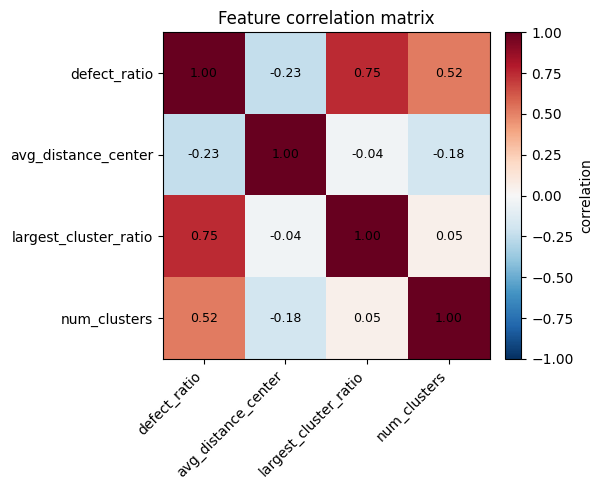

In [19]:
corr_matrix = df_labeled[feature_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")

ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right")
ax.set_yticklabels(feature_cols)

for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="correlation")
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

### Training

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

In [21]:
TEST_SIZE = 0.2
N_SPLITS = 5

FEATURE_SET = f"Baseline_features"

df_train_val, df_test = train_test_split(
    df_labeled,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=df_labeled["failureType"]
)

X_train_val = df_train_val[feature_cols].copy()
y_train_val = df_train_val["failureType"].copy()
X_test = df_test[feature_cols].copy()
y_test = df_test["failureType"].copy()

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

le = LabelEncoder()
y_train_val_enc = le.fit_transform(y_train_val)

model_results = []

print("Train+Val:", X_train_val.shape)
print("Test:", X_test.shape)
print("Feature set:", FEATURE_SET)

Train+Val: (138360, 4)
Test: (34590, 4)
Feature set: Baseline_features


#### Logistic Regression

In [22]:
lr_model = Pipeline([
    ("normalize_features", StandardScaler()),
    ("log_reg_model", LogisticRegression(max_iter=2000, random_state=42))
])
lr_cv_scores = cross_val_score(lr_model, X_train_val, y_train_val, cv=skf, scoring="f1_macro", n_jobs=-1)
print(f"CV macro F1: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")

lr_model.fit(X_train_val, y_train_val)

CV macro F1: 0.5412 ± 0.0037


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('normalize_features', ...), ('log_reg_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some p

#### Random Forest

In [23]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_cv_scores = cross_val_score(rf_model, X_train_val, y_train_val, cv=skf, scoring="f1_macro", n_jobs=-1)
print(f"CV macro F1: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

rf_model.fit(X_train_val, y_train_val)

feat_imp = pd.Series(rf_model.feature_importances_, index=X_train_val.columns)
print(feat_imp.sort_values(ascending=False).head(20))

CV macro F1: 0.6608 ± 0.0054
largest_cluster_ratio    0.447358
avg_distance_center      0.267871
defect_ratio             0.204070
num_clusters             0.080700
dtype: float64


#### XGBoost

In [24]:
xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=len(classes),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)
xgb_cv_scores = cross_val_score(xgb_base, X_train_val, y_train_val_enc, cv=skf, scoring="f1_macro", n_jobs=-1)
print(f"CV macro F1: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

xgb_base.fit(X_train_val, y_train_val_enc)


class XGBLabelWrapper:
    def __init__(self, model, label_encoder):
        self.model = model
        self.label_encoder = label_encoder

    def predict(self, X):
        preds_enc = self.model.predict(X)
        return self.label_encoder.inverse_transform(preds_enc.astype(int))


xgb_model = XGBLabelWrapper(xgb_base, le)

CV macro F1: 0.6069 ± 0.0106


#### SVM

In [25]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ("normalize_features", StandardScaler()),
    ("svm_model", SVC(kernel="rbf", random_state=42))
])
svm_cv_scores = cross_val_score(svm_model, X_train_val, y_train_val, cv=skf, scoring="f1_macro", n_jobs=-1)
print(f"CV macro F1: {svm_cv_scores.mean():.4f} ± {svm_cv_scores.std():.4f}")

svm_model.fit(X_train_val, y_train_val)

CV macro F1: 0.6289 ± 0.0072


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('normalize_features', ...), ('svm_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


#### Neural Network

In [26]:
from sklearn.neural_network import MLPClassifier

nn_model = Pipeline([
    ("normalize_features", StandardScaler()),
    ("mlp_model", MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=512,
        learning_rate_init=1e-3,
        max_iter=500,
        random_state=42
    ))
])
nn_cv_scores = cross_val_score(nn_model, X_train_val, y_train_val, cv=skf, scoring="f1_macro", n_jobs=-1)
print(f"CV macro F1: {nn_cv_scores.mean():.4f} ± {nn_cv_scores.std():.4f}")

nn_model.fit(X_train_val, y_train_val)

CV macro F1: 0.6384 ± 0.0058


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('normalize_features', ...), ('mlp_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(32,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regulariz

### Evaluation

In [27]:
from sklearn.metrics import classification_report

In [32]:
def get_model_repr(model):
    if hasattr(model, "named_steps"):
        return str(list(model.named_steps.values())[-1])
    if hasattr(model, "model"):
        return str(model.model)
    return str(model)


def evaluate_classical_model(model, name, X, y, classes, cv_scores=None, feature_set=None, batch_size=50, warmup_batches=5):
    # batched inference timing (matches DL harness: warmup + per-batch loop)
    n_warmup = min(warmup_batches, max(1, len(X) // batch_size))
    for i in range(n_warmup):
        _ = model.predict(X[i*batch_size:(i+1)*batch_size])

    t_total = 0.0
    n_total = 0
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size]
        t0 = time.perf_counter()
        _ = model.predict(xb)
        t_total += time.perf_counter() - t0
        n_total += len(xb)

    inference_s = t_total
    inference_per_sample_ms = inference_s / n_total * 1000

    # full-set predict for metrics (separate from timing)
    preds = model.predict(X)

    report = classification_report(
        y, preds,
        labels=classes,
        target_names=classes,
        output_dict=True,
        zero_division=0
    )
    print(f"\nMetrics for {name}:\n")
    print(f"{'Class':<12} {'F1':>10} {'Precision':>12} {'Recall':>10}")
    print("-" * 48)
    for cls in classes:
        print(
            f"{cls:<12} "
            f"{report[cls]['f1-score']:>10.4f} "
            f"{report[cls]['precision']:>12.4f} "
            f"{report[cls]['recall']:>10.4f}"
        )
    print("-" * 48)
    print(
        f"{'macro avg':<12} "
        f"{report['macro avg']['f1-score']:>10.4f} "
        f"{report['macro avg']['precision']:>12.4f} "
        f"{report['macro avg']['recall']:>10.4f}"
    )
    print(
        f"{'weighted avg':<12} "
        f"{report['weighted avg']['f1-score']:>10.4f} "
        f"{report['weighted avg']['precision']:>12.4f} "
        f"{report['weighted avg']['recall']:>10.4f}"
    )
    print(f"\nOverall Accuracy: {report['accuracy']:.4f}")
    if cv_scores is not None:
        print(f"CV macro F1:      {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Inference time:   {inference_s:.3f}s total, {inference_per_sample_ms:.4f}ms/sample (batch_size={batch_size})")

    result = {
        "name": name,
        "feature_set": feature_set,
        "n_features": X.shape[1],
        "cv_mean_f1": float(cv_scores.mean()) if cv_scores is not None else None,
        "cv_std_f1": float(cv_scores.std()) if cv_scores is not None else None,
        "test_accuracy": report["accuracy"],
        "test_macro_f1": report["macro avg"]["f1-score"],
        "test_macro_precision": report["macro avg"]["precision"],
        "test_macro_recall": report["macro avg"]["recall"],
        "test_weighted_f1": report["weighted avg"]["f1-score"],
        "inference_time_s": inference_s,
        "inference_time_per_sample_ms": inference_per_sample_ms,
        "inference_batch_size": batch_size,
        "n_test_samples": len(X),
        "model_params": get_model_repr(model),
    }
    for cls in classes:
        result[f"f1_{cls}"] = report[cls]["f1-score"]
        result[f"precision_{cls}"] = report[cls]["precision"]
        result[f"recall_{cls}"] = report[cls]["recall"]
    return result

#### Logistic Regression

In [33]:
model_results.append(
    evaluate_classical_model(
        lr_model, "Logistic Regression", X_test, y_test, classes,
        cv_scores=lr_cv_scores, feature_set=FEATURE_SET
    )
)


Metrics for Logistic Regression:

Class                F1    Precision     Recall
------------------------------------------------
none             0.9766       0.9608     0.9930
Edge-Ring        0.8813       0.8674     0.8957
Edge-Loc         0.4110       0.4926     0.3526
Center           0.6571       0.6453     0.6694
Loc              0.2424       0.4854     0.1616
Scratch          0.0000       0.0000     0.0000
Random           0.6185       0.6185     0.6185
Donut            0.1611       0.3158     0.1081
Near-full        0.9836       0.9677     1.0000
------------------------------------------------
macro avg        0.5480       0.5948     0.5332
weighted avg     0.9200       0.9134     0.9315

Overall Accuracy: 0.9315
CV macro F1:      0.5412 ± 0.0037
Inference time:   0.258s total, 0.0075ms/sample (batch_size=50)


#### Random Forest

In [34]:
model_results.append(
    evaluate_classical_model(
        rf_model, "Random Forest", X_test, y_test, classes,
        cv_scores=rf_cv_scores, feature_set=FEATURE_SET
    )
)


Metrics for Random Forest:

Class                F1    Precision     Recall
------------------------------------------------
none             0.9832       0.9740     0.9925
Edge-Ring        0.9160       0.9198     0.9122
Edge-Loc         0.5429       0.5599     0.5270
Center           0.7437       0.7921     0.7008
Loc              0.3938       0.4709     0.3384
Scratch          0.1795       0.3836     0.1172
Random           0.7233       0.6875     0.7630
Donut            0.4149       0.5065     0.3514
Near-full        0.9836       0.9677     1.0000
------------------------------------------------
macro avg        0.6534       0.6958     0.6336
weighted avg     0.9393       0.9366     0.9439

Overall Accuracy: 0.9439
CV macro F1:      0.6608 ± 0.0054
Inference time:   12.739s total, 0.3683ms/sample (batch_size=50)


#### XGBoost

In [35]:
model_results.append(
    evaluate_classical_model(
        xgb_model, "XGBoost", X_test, y_test, classes,
        cv_scores=xgb_cv_scores, feature_set=FEATURE_SET
    )
)


Metrics for XGBoost:

Class                F1    Precision     Recall
------------------------------------------------
none             0.9825       0.9723     0.9930
Edge-Ring        0.9217       0.9251     0.9184
Edge-Loc         0.5422       0.5627     0.5231
Center           0.7114       0.7637     0.6659
Loc              0.3794       0.4711     0.3175
Scratch          0.1712       0.4717     0.1046
Random           0.6442       0.5849     0.7168
Donut            0.3068       0.4154     0.2432
Near-full        0.6545       0.7200     0.6000
------------------------------------------------
macro avg        0.5904       0.6541     0.5647
weighted avg     0.9369       0.9344     0.9423

Overall Accuracy: 0.9423
CV macro F1:      0.6069 ± 0.0106
Inference time:   1.602s total, 0.0463ms/sample (batch_size=50)


#### SVM

In [36]:
model_results.append(
    evaluate_classical_model(
        svm_model, "Support Vector Machine", X_test, y_test, classes,
        cv_scores=svm_cv_scores, feature_set=FEATURE_SET
    )
)


Metrics for Support Vector Machine:

Class                F1    Precision     Recall
------------------------------------------------
none             0.9795       0.9638     0.9957
Edge-Ring        0.9201       0.9364     0.9044
Edge-Loc         0.5283       0.5740     0.4894
Center           0.7190       0.8032     0.6508
Loc              0.3570       0.5158     0.2730
Scratch          0.0000       0.0000     0.0000
Random           0.7206       0.6571     0.7977
Donut            0.3879       0.5926     0.2883
Near-full        0.9836       0.9677     1.0000
------------------------------------------------
macro avg        0.6218       0.6678     0.5999
weighted avg     0.9333       0.9279     0.9417

Overall Accuracy: 0.9417
CV macro F1:      0.6289 ± 0.0072
Inference time:   24.719s total, 0.7146ms/sample (batch_size=50)


#### Neural Network

In [37]:
model_results.append(
    evaluate_classical_model(
        nn_model, "Neural Network", X_test, y_test, classes,
        cv_scores=nn_cv_scores, feature_set=FEATURE_SET
    )
)


Metrics for Neural Network:

Class                F1    Precision     Recall
------------------------------------------------
none             0.9817       0.9697     0.9941
Edge-Ring        0.9175       0.9130     0.9220
Edge-Loc         0.5235       0.5875     0.4721
Center           0.6965       0.7260     0.6694
Loc              0.3799       0.5193     0.2994
Scratch          0.0625       0.4706     0.0335
Random           0.6856       0.6186     0.7688
Donut            0.4186       0.4327     0.4054
Near-full        0.9667       0.9667     0.9667
------------------------------------------------
macro avg        0.6258       0.6893     0.6146
weighted avg     0.9352       0.9327     0.9422

Overall Accuracy: 0.9422
CV macro F1:      0.6384 ± 0.0058
Inference time:   0.303s total, 0.0088ms/sample (batch_size=50)


In [38]:
results_df = pd.DataFrame(model_results).sort_values("test_macro_f1", ascending=False)
results_df.to_csv(f"checkpoints/classical_results_{FEATURE_SET}.csv", index=False)

print(results_df[["name", "n_features", "cv_mean_f1", "cv_std_f1", "test_macro_f1", "test_accuracy"]].to_string(index=False))

                  name  n_features  cv_mean_f1  cv_std_f1  test_macro_f1  test_accuracy
         Random Forest           4    0.660754   0.005371       0.653428       0.943943
         Random Forest           4    0.660754   0.005371       0.653428       0.943943
        Neural Network           4    0.638420   0.005773       0.625831       0.942238
Support Vector Machine           4    0.628885   0.007169       0.621781       0.941688
               XGBoost           4    0.606904   0.010582       0.590445       0.942324
   Logistic Regression           4    0.541203   0.003724       0.547966       0.931483
   Logistic Regression           4    0.541203   0.003724       0.547966       0.931483


In [39]:
timing_df = (
    pd.DataFrame(model_results)
    [["name", "n_features", "test_macro_f1", "inference_time_s", "inference_time_per_sample_ms", "n_test_samples"]]
    .sort_values("inference_time_per_sample_ms")
    .round(6)
)
print(timing_df.to_string(index=False))

                  name  n_features  test_macro_f1  inference_time_s  inference_time_per_sample_ms  n_test_samples
   Logistic Regression           4       0.547966          0.257972                      0.007458           34590
        Neural Network           4       0.625831          0.303308                      0.008769           34590
   Logistic Regression           4       0.547966          0.370792                      0.010720           34590
               XGBoost           4       0.590445          1.602471                      0.046328           34590
         Random Forest           4       0.653428         12.739086                      0.368288           34590
         Random Forest           4       0.653428         19.669119                      0.568636           34590
Support Vector Machine           4       0.621781         24.719456                      0.714642           34590


## Engineered Features from Wu et al. 2015

### Radon-based features

The Radon transform projects the defect mask along straight lines parameterized by `(ρ, θ)`, producing a 2D response `G(ρ, θ)` whose shape characterizes the failure pattern:

- **Center** — narrow strong band at mid-ρ across all θ
- **Donut** — wider band at mid-ρ
- **Edge-Ring** — strong response at the extremes of ρ
- **Scratch / Edge-Loc** — sharp angle-dependent peaks across θ

After min-max normalizing `G`, two summaries are computed:
- **R_μ** — mean of `G` over θ at each ρ
- **R_σ** — standard deviation of `G` over θ at each ρ

Each is resampled with cubic interpolation to a fixed length of 20, giving **40 features total**. Averaging over θ makes them rotation-invariant; resampling to fixed length makes them scale-invariant across wafer sizes.

In [40]:
from skimage.transform import radon
from scipy.interpolate import interp1d
from joblib import Parallel, delayed

In [41]:
N_RADON = 20
N_THETA = 90

radon_cols = [f"rmu_{i}" for i in range(N_RADON)] + [f"rsig_{i}" for i in range(N_RADON)]


def radon_features(wm):
    defects = (wm == 2).astype(np.float64)
    if defects.sum() == 0:
        return np.zeros(2 * N_RADON)

    theta = np.linspace(0.0, 180.0, N_THETA, endpoint=False)
    g = radon(defects, theta=theta, circle=False)

    g_min, g_max = g.min(), g.max()
    if g_max - g_min > 0:
        g = (g - g_min) / (g_max - g_min)

    g_mu = g.mean(axis=1)
    g_sigma = g.std(axis=1)

    if len(g_mu) < 4:
        return np.zeros(2 * N_RADON)

    x_old = np.linspace(0.0, 1.0, len(g_mu))
    x_new = np.linspace(0.0, 1.0, N_RADON)
    r_mu = interp1d(x_old, g_mu, kind="cubic")(x_new)
    r_sigma = interp1d(x_old, g_sigma, kind="cubic")(x_new)

    return np.concatenate([r_mu, r_sigma])


results = Parallel(n_jobs=-1, batch_size=200, verbose=5)(
    delayed(radon_features)(wm) for wm in df_labeled["waferMap"]
)
df_labeled[radon_cols] = np.vstack(results)

print(
    df_labeled.groupby("failureType")[radon_cols]
    .mean()
    .reindex(classes)
    .round(3)
    .T
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 10022 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done 28022 tasks      | elapsed:   23.5s
[Parallel(n_jobs=-1)]: Done 53222 tasks      | elapsed:   34.4s
[Parallel(n_jobs=-1)]: Done 85622 tasks      | elapsed:   48.9s
[Parallel(n_jobs=-1)]: Done 125222 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 170330 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 172950 out of 172950 | elapsed:  1.5min finished


failureType   none  Edge-Ring  Edge-Loc  Center    Loc  Scratch  Random  \
rmu_0        0.000      0.000     0.000   0.000  0.000    0.000   0.000   
rmu_1       -0.000      0.000     0.000   0.000 -0.000   -0.000  -0.000   
rmu_2        0.000     -0.000     0.000   0.000  0.000    0.000   0.000   
rmu_3        0.110      0.298     0.089   0.093  0.067    0.060   0.117   
rmu_4        0.279      0.453     0.308   0.229  0.191    0.164   0.350   
rmu_5        0.290      0.366     0.323   0.252  0.233    0.190   0.463   
rmu_6        0.304      0.342     0.317   0.277  0.264    0.200   0.539   
rmu_7        0.319      0.335     0.320   0.329  0.301    0.214   0.599   
rmu_8        0.333      0.338     0.326   0.448  0.324    0.220   0.641   
rmu_9        0.364      0.348     0.346   0.614  0.344    0.237   0.669   
rmu_10       0.373      0.361     0.355   0.630  0.349    0.244   0.673   
rmu_11       0.335      0.337     0.329   0.457  0.325    0.224   0.643   
rmu_12       0.320      0

#### Radon transform visualization

For each class, one wafer is sampled and shown alongside its normalized Radon response `G(ρ, θ)` and the derived features `R_μ` and `R_σ`. Compare to Fig. 2 of Wu et al.

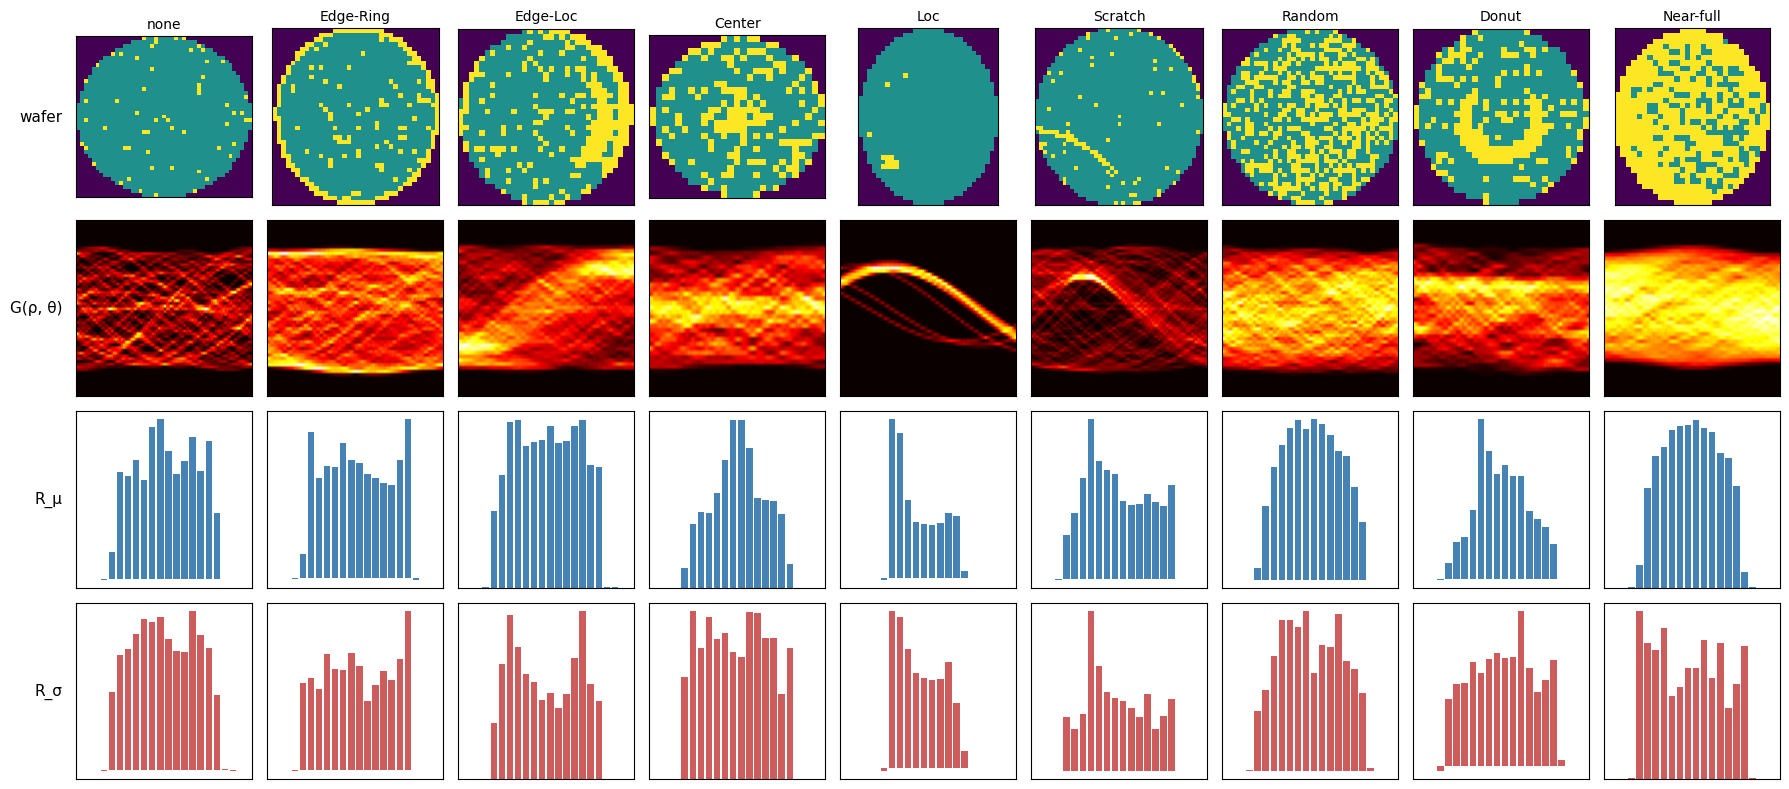

In [42]:
def compute_radon_g(wm):
    defects = (wm == 2).astype(np.float64)
    theta = np.linspace(0.0, 180.0, N_THETA, endpoint=False)
    g = radon(defects, theta=theta, circle=False)
    g_min, g_max = g.min(), g.max()
    if g_max - g_min > 0:
        g = (g - g_min) / (g_max - g_min)
    return g


rng = np.random.default_rng(100)
row_labels = ["wafer", "G(ρ, θ)", "R_μ", "R_σ"]
fig, axes = plt.subplots(4, len(classes), figsize=(2 * len(classes), 8))

for j, cls in enumerate(classes):
    subset = df_labeled[df_labeled["failureType"] == cls]
    if len(subset) == 0:
        for i in range(4):
            axes[i, j].axis("off")
        continue

    row = subset.iloc[rng.integers(0, len(subset))]
    wm = row["waferMap"]
    g = compute_radon_g(wm)
    r_mu = row[[f"rmu_{k}" for k in range(N_RADON)]].values.astype(float)
    r_sigma = row[[f"rsig_{k}" for k in range(N_RADON)]].values.astype(float)

    axes[0, j].imshow(wm, cmap="viridis")
    axes[0, j].set_title(cls, fontsize=10)
    axes[0, j].set_xticks([])
    axes[0, j].set_yticks([])

    axes[1, j].imshow(g, cmap="hot", aspect="auto",
                      extent=[0, 180, g.shape[0], 0])
    axes[1, j].set_xticks([])
    axes[1, j].set_yticks([])

    axes[2, j].bar(range(N_RADON), r_mu, color="steelblue")
    axes[2, j].set_xticks([])
    axes[2, j].set_yticks([])

    axes[3, j].bar(range(N_RADON), r_sigma, color="indianred")
    axes[3, j].set_xticks([])
    axes[3, j].set_yticks([])

for i, lbl in enumerate(row_labels):
    axes[i, 0].set_ylabel(lbl, fontsize=11, rotation=0, ha="right", va="center", labelpad=10)

plt.tight_layout()
plt.show()

### Geometry-based features

1. **Regional** — measured on the most salient connected defect regions
2. **Statistical** — ratio of defective dies, globally and near the edge
3. **Linear** — count of straight line segments in the defects

Two "salient regions" are defined per wafer:
- **sa** — the connected defect region with the **largest area**
- **sp** — the connected defect region with the **largest perimeter**

Most regional features are computed for both, since `sa` captures "blobby" patterns (Center, Donut) while `sp` captures "stretched" patterns (Scratch, Edge-Loc)

#### Regional attributes

Six shape descriptors are computed for `sa` and two more (area and perimeter ratios) for a single region each. Together that's 14 features.

- **sa_area_ratio** — area of `sa` divided by wafer area. Large for Center, Donut, Near-full; tiny for Scratch.
- **sp_perim_ratio** — perimeter of `sp` divided by wafer radius. Large for Edge-Ring and long Scratches.
- **max_dist / min_dist** — farthest and nearest point of the region from the wafer center, normalized by wafer radius. Min distance near 0 ⇒ region touches center (Center); max near 1 -> region reaches the edge (Edge-Ring).
- **major_axis / minor_axis** — lengths of the fitted ellipse's axes, normalized by wafer radius. Disambiguates elongated (Scratch) from compact (Center) shapes.
- **solidity** — defective pixels in region divided by area of its convex hull. Dense blobs have solidity near 1; sparse or fragmented regions are lower.
- **eccentricity** — shape of the fitted ellipse, computed as `sqrt(1 − minor²/major²)`. 0 = perfect circle, 1 = a line. Scratches approach 1.

In [43]:
regional_cols = [
    "sa_area_ratio", "sp_perim_ratio",
    "sa_max_dist", "sa_min_dist", "sa_major_axis", "sa_minor_axis",
    "sa_solidity", "sa_eccentricity",
    "sp_max_dist", "sp_min_dist", "sp_major_axis", "sp_minor_axis",
    "sp_solidity", "sp_eccentricity",
]


def regional_attributes(wm):
    valid = (wm > 0)
    defects = (wm == 2)
    n_valid = int(valid.sum())

    if n_valid == 0 or defects.sum() == 0:
        return np.zeros(len(regional_cols))

    r = np.sqrt(n_valid / np.pi)
    vy, vx = np.argwhere(valid).mean(axis=0)

    labeled = label(defects, connectivity=2)
    props = regionprops(labeled)
    if not props:
        return np.zeros(len(regional_cols))

    sa = max(props, key=lambda p: p.area)
    sp = max(props, key=lambda p: p.perimeter if p.perimeter > 0 else 0)

    def describe(reg):
        dy = reg.coords[:, 0] - vy
        dx = reg.coords[:, 1] - vx
        d_sq = dy * dy + dx * dx
        mj, mi = reg.axis_major_length, reg.axis_minor_length
        ecc = np.sqrt(max(1.0 - (mi ** 2) / (mj ** 2), 0.0)) if mj > 0 else 0.0
        return np.sqrt(d_sq.max()) / r, np.sqrt(d_sq.min()) / r, mj / r, mi / r, reg.solidity, ecc

    sa_desc = describe(sa)
    sp_desc = sa_desc if sp is sa else describe(sp)

    return np.array([
        sa.area / (np.pi * r * r),
        sp.perimeter / r,
        *sa_desc,
        *sp_desc,
    ])


results = Parallel(n_jobs=-1, batch_size=200, verbose=5)(
    delayed(regional_attributes)(wm) for wm in df_labeled["waferMap"]
)
df_labeled[regional_cols] = np.vstack(results)

print(
    df_labeled.groupby("failureType")[regional_cols]
    .mean()
    .reindex(classes)
    .round(3)
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 10022 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 28022 tasks      | elapsed:   11.4s
[Parallel(n_jobs=-1)]: Done 53222 tasks      | elapsed:   19.2s
[Parallel(n_jobs=-1)]: Done 85622 tasks      | elapsed:   30.5s
[Parallel(n_jobs=-1)]: Done 125222 tasks      | elapsed:   43.3s
[Parallel(n_jobs=-1)]: Done 170142 tasks      | elapsed:   57.9s
[Parallel(n_jobs=-1)]: Done 172950 out of 172950 | elapsed:   58.3s finished


             sa_area_ratio  sp_perim_ratio  sa_max_dist  sa_min_dist  \
failureType                                                            
none                 0.010           0.410        0.848        0.688   
Edge-Ring            0.096           7.139        1.033        0.827   
Edge-Loc             0.076           2.574        1.023        0.667   
Center               0.089           2.531        0.503        0.036   
Loc                  0.058           2.009        0.837        0.379   
Scratch              0.027           1.435        0.915        0.417   
Random               0.387          16.645        1.010        0.073   
Donut                0.191           6.756        0.786        0.176   
Near-full            0.873          13.608        1.039        0.026   

             sa_major_axis  sa_minor_axis  sa_solidity  sa_eccentricity  \
failureType                                                               
none                 0.376          0.146        0.709   

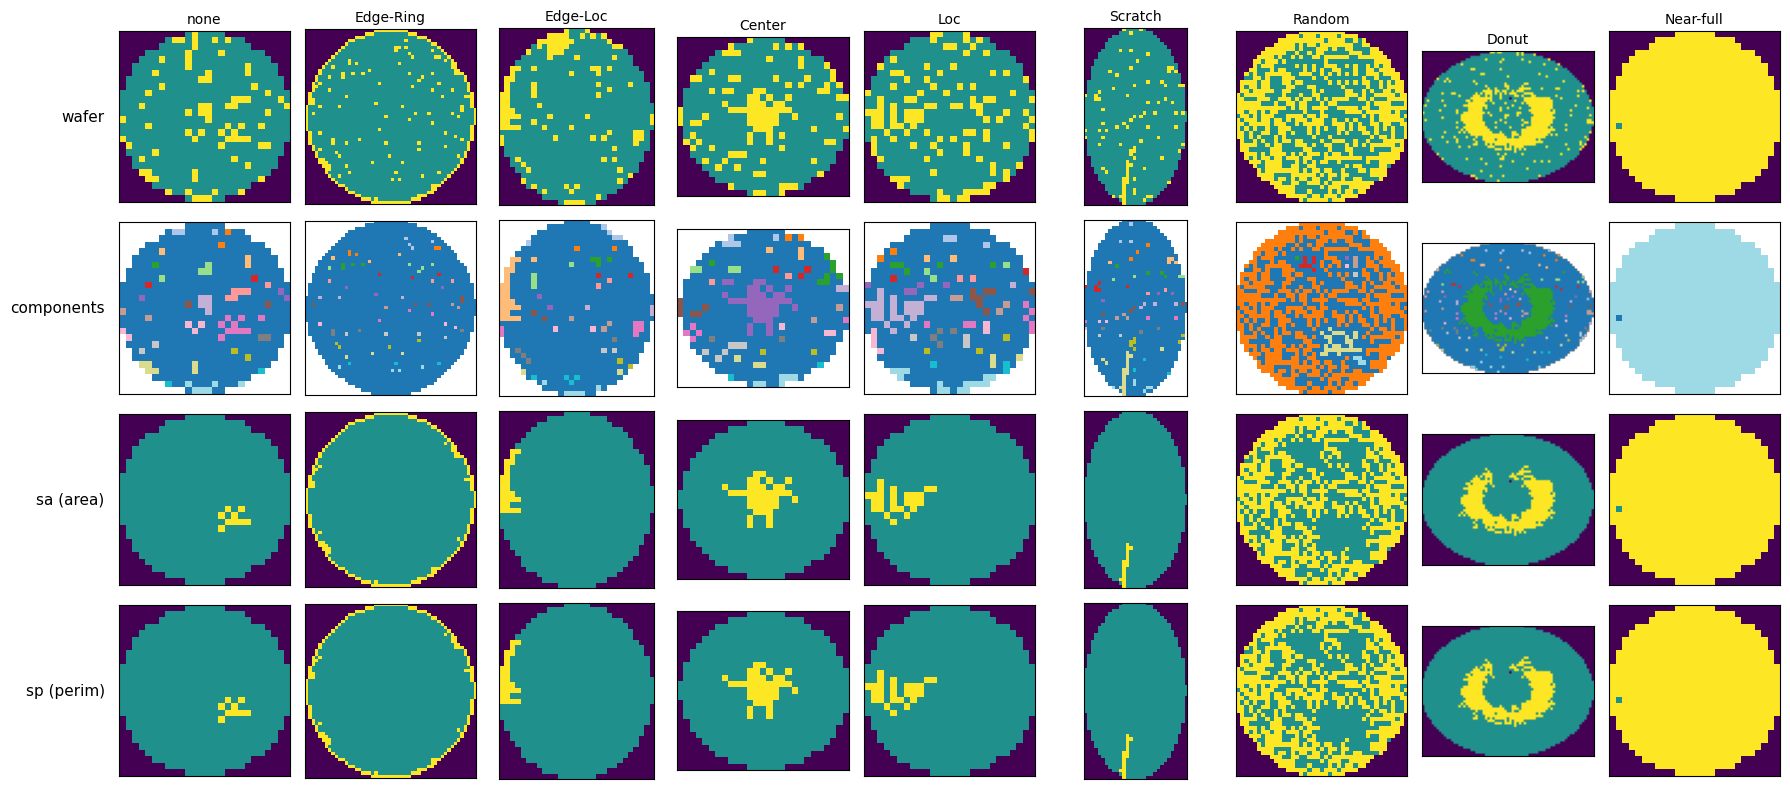

In [44]:
def get_salient_regions(wm):
    defects = (wm == 2)
    if defects.sum() == 0:
        return None, None, None
    labeled = label(defects, connectivity=2)
    props = regionprops(labeled)
    if not props:
        return labeled, None, None
    sa = max(props, key=lambda p: p.area)
    sp = max(props, key=lambda p: p.perimeter if p.perimeter > 0 else 0)
    return labeled, (labeled == sa.label), (labeled == sp.label)


rng = np.random.default_rng(42)
row_labels = ["wafer", "components", "sa (area)", "sp (perim)"]
fig, axes = plt.subplots(4, len(classes), figsize=(2 * len(classes), 8))

for j, cls in enumerate(classes):
    subset = df_labeled[df_labeled["failureType"] == cls]
    if len(subset) == 0:
        for i in range(4):
            axes[i, j].axis("off")
        continue

    row = subset.iloc[rng.integers(0, len(subset))]
    wm = row["waferMap"]
    labeled, sa_mask, sp_mask = get_salient_regions(wm)

    axes[0, j].imshow(wm, cmap="viridis")
    axes[0, j].set_title(cls, fontsize=10)

    comp_disp = labeled.astype(float) if labeled is not None else np.zeros_like(wm, dtype=float)
    comp_disp[~(wm > 0)] = np.nan
    axes[1, j].imshow(comp_disp, cmap="tab20")

    sa_disp = (wm > 0).astype(float)
    if sa_mask is not None:
        sa_disp[sa_mask] = 2
    axes[2, j].imshow(sa_disp, cmap="viridis")

    sp_disp = (wm > 0).astype(float)
    if sp_mask is not None:
        sp_disp[sp_mask] = 2
    axes[3, j].imshow(sp_disp, cmap="viridis")

    for i in range(4):
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

for i, lbl in enumerate(row_labels):
    axes[i, 0].set_ylabel(lbl, fontsize=11, rotation=0, ha="right", va="center", labelpad=10)

plt.tight_layout()
plt.show()

#### Statistical attributes — RDD

**RDD** = Ratio of Defective Dies.

- **global_rdd** — defective dies / total valid dies across the entire wafer.
- **ring1_rdd** — RDD measured only on the outermost ring of dies.
- **ring2_rdd** — RDD measured on the second-outermost ring.

The two ring features matter because edge-related failures (Edge-Ring, Edge-Loc) are defined by defects concentrated on the boundary. Rings are found by successive 8-connected binary erosion of the valid-die mask.

In [45]:
stat_cols = ["global_rdd", "ring1_rdd", "ring2_rdd"]


def statistical_attributes(wm):
    valid = (wm > 0)
    defects = (wm == 2)
    n_valid = int(valid.sum())
    if n_valid == 0:
        return np.zeros(3)

    struct = np.ones((3, 3), dtype=bool)
    eroded1 = binary_erosion(valid, structure=struct)
    eroded2 = binary_erosion(eroded1, structure=struct)
    ring1 = valid & ~eroded1
    ring2 = eroded1 & ~eroded2

    n_ring1, n_ring2 = int(ring1.sum()), int(ring2.sum())

    return np.array([
        defects.sum() / n_valid,
        (defects & ring1).sum() / n_ring1 if n_ring1 > 0 else 0.0,
        (defects & ring2).sum() / n_ring2 if n_ring2 > 0 else 0.0,
    ])


results = Parallel(n_jobs=-1, batch_size=500, verbose=5)(
    delayed(statistical_attributes)(wm) for wm in df_labeled["waferMap"]
)
df_labeled[stat_cols] = np.vstack(results)

print(
    df_labeled.groupby("failureType")[stat_cols]
    .mean()
    .reindex(classes)
    .round(3)
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 25022 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 70022 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 133022 tasks      | elapsed:    4.4s


             global_rdd  ring1_rdd  ring2_rdd
failureType                                  
none              0.106      0.218      0.098
Edge-Ring         0.151      0.828      0.174
Edge-Loc          0.183      0.387      0.230
Center            0.232      0.336      0.159
Loc               0.150      0.230      0.125
Scratch           0.101      0.206      0.102
Random            0.481      0.594      0.470
Donut             0.277      0.272      0.124
Near-full         0.877      0.861      0.838


[Parallel(n_jobs=-1)]: Done 172436 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 172950 out of 172950 | elapsed:    5.0s finished


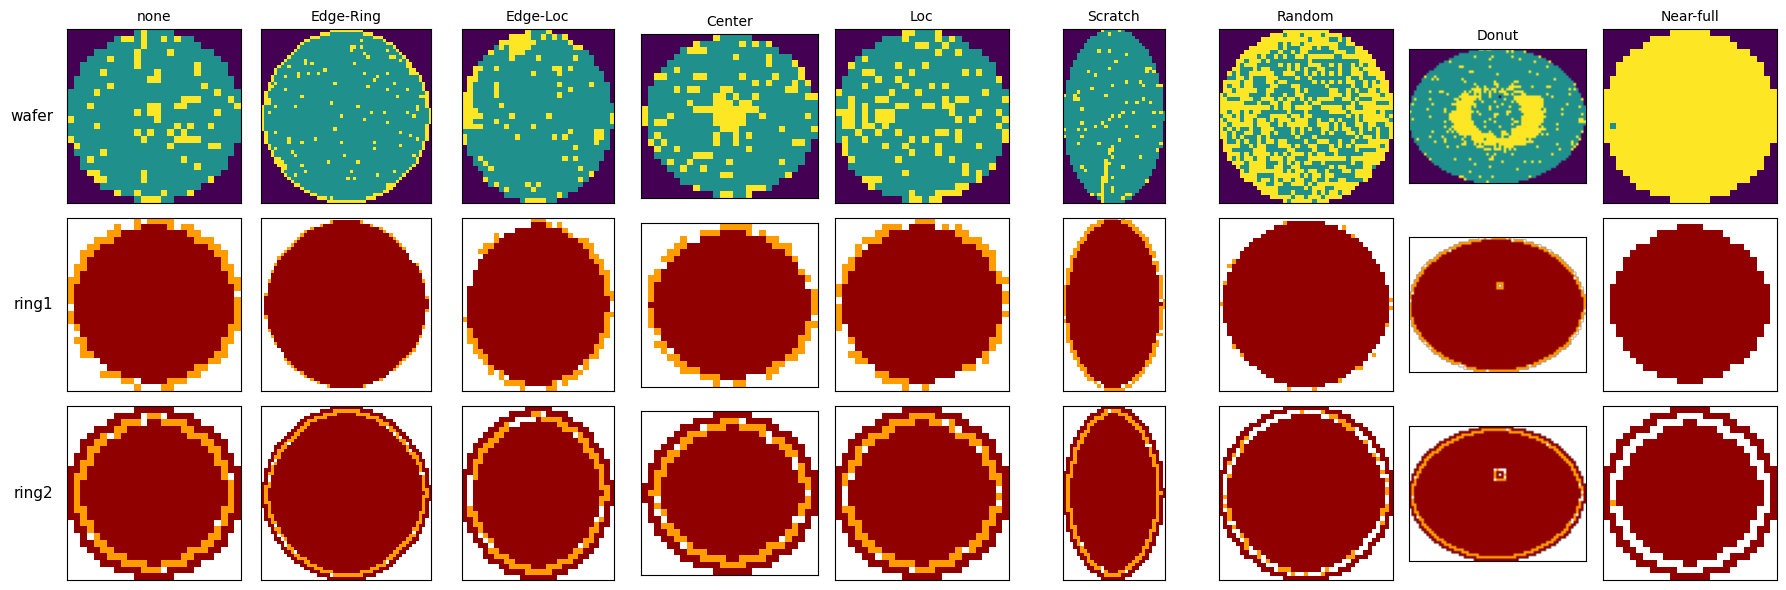

In [46]:
def compute_rings(wm):
    valid = (wm > 0)
    struct = np.ones((3, 3), dtype=bool)
    eroded1 = binary_erosion(valid, structure=struct)
    eroded2 = binary_erosion(eroded1, structure=struct)
    return valid, valid & ~eroded1, eroded1 & ~eroded2


def ring_overlay(wm, ring_mask):
    defects = (wm == 2)
    valid = (wm > 0)
    disp = np.full(wm.shape, np.nan)
    disp[valid] = 0.2
    disp[ring_mask] = 0.6
    disp[ring_mask & defects] = 1.0
    return disp


rng = np.random.default_rng(42)
row_labels = ["wafer", "ring1", "ring2"]
fig, axes = plt.subplots(3, len(classes), figsize=(2 * len(classes), 6))

for j, cls in enumerate(classes):
    subset = df_labeled[df_labeled["failureType"] == cls]
    if len(subset) == 0:
        for i in range(3):
            axes[i, j].axis("off")
        continue

    wm = subset.iloc[rng.integers(0, len(subset))]["waferMap"]
    _, ring1, ring2 = compute_rings(wm)

    axes[0, j].imshow(wm, cmap="viridis")
    axes[0, j].set_title(cls, fontsize=10)
    axes[1, j].imshow(ring_overlay(wm, ring1), cmap="hot", vmin=0, vmax=1)
    axes[2, j].imshow(ring_overlay(wm, ring2), cmap="hot", vmin=0, vmax=1)

    for i in range(3):
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

for i, lbl in enumerate(row_labels):
    axes[i, 0].set_ylabel(lbl, fontsize=11, rotation=0, ha="right", va="center", labelpad=10)

plt.tight_layout()
plt.show()

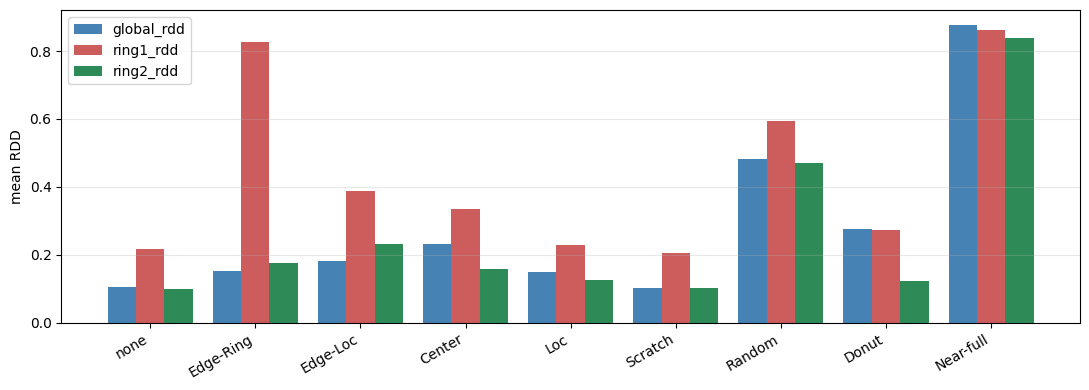

In [47]:
mean_stats = (
    df_labeled.groupby("failureType")[stat_cols]
    .mean()
    .reindex(classes)
)

x = np.arange(len(classes))
width = 0.27
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - width, mean_stats["global_rdd"], width, label="global_rdd", color="steelblue")
ax.bar(x,         mean_stats["ring1_rdd"],  width, label="ring1_rdd",  color="indianred")
ax.bar(x + width, mean_stats["ring2_rdd"],  width, label="ring2_rdd",  color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.set_ylabel("mean RDD")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Linear attribute (Hough line count)

Straight line segments in the defect pattern are a near-perfect signature for **Scratch**. The Hough transform finds candidate lines by voting in parameter space; each defect die votes for every `(ρ, θ)` line that could pass through it, and peaks in the accumulator indicate real lines.

Following the paper's rules:
- A detected line must be at least **10% of the wafer's diameter** long.
- Gaps along a line are tolerated up to **3% of the diameter** (broken lines are still counted).

The final feature is just the **number of lines detected**. Non-pattern wafers and blob-like patterns score 0; Scratches typically score 1–2.

In [48]:
HOUGH_THETA = np.linspace(-np.pi / 2, np.pi / 2, 90, endpoint=False)
HOUGH_THRESHOLD = 10


def hough_line_count(wm):
    valid = (wm > 0)
    defects = (wm == 2)
    n_valid = int(valid.sum())
    n_defects = int(defects.sum())

    if n_valid == 0 or n_defects < HOUGH_THRESHOLD:
        return 0

    diameter = 2.0 * np.sqrt(n_valid / np.pi)
    lines = probabilistic_hough_line(
        defects.astype(np.uint8),
        threshold=HOUGH_THRESHOLD,
        line_length=max(int(0.10 * diameter), 1),
        line_gap=max(int(0.03 * diameter), 1),
        theta=HOUGH_THETA,
    )
    return len(lines)


results = Parallel(n_jobs=-1, batch_size=200, verbose=5)(
    delayed(hough_line_count)(wm) for wm in df_labeled["waferMap"]
)
df_labeled["num_lines"] = results

print(
    df_labeled.groupby("failureType")["num_lines"]
    .mean()
    .reindex(classes)
    .round(3)
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 10022 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 28022 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 53222 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 85622 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 125222 tasks      | elapsed:    3.6s


failureType
none          0.917
Edge-Ring    13.096
Edge-Loc      8.502
Center        9.327
Loc           6.322
Scratch       3.355
Random       49.946
Donut        25.404
Near-full    43.859
Name: num_lines, dtype: float64


[Parallel(n_jobs=-1)]: Done 170894 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 172950 out of 172950 | elapsed:    4.7s finished


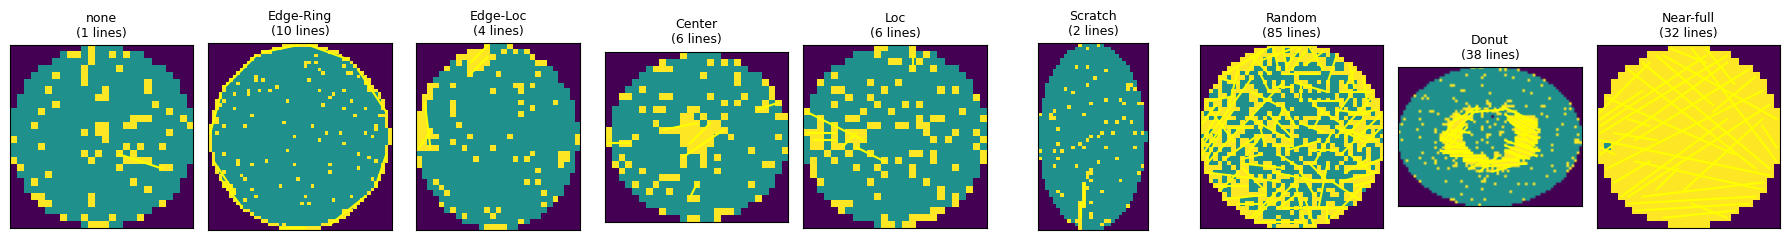

In [49]:
def detect_lines(wm):
    valid = (wm > 0)
    defects = (wm == 2)
    n_valid = int(valid.sum())
    n_defects = int(defects.sum())

    if n_valid == 0 or n_defects < HOUGH_THRESHOLD:
        return []

    diameter = 2.0 * np.sqrt(n_valid / np.pi)
    return probabilistic_hough_line(
        defects.astype(np.uint8),
        threshold=HOUGH_THRESHOLD,
        line_length=max(int(0.10 * diameter), 1),
        line_gap=max(int(0.03 * diameter), 1),
        theta=HOUGH_THETA,
    )


rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, len(classes), figsize=(2 * len(classes), 2.5))

for j, cls in enumerate(classes):
    subset = df_labeled[df_labeled["failureType"] == cls]
    if len(subset) == 0:
        axes[j].axis("off")
        continue

    wm = subset.iloc[rng.integers(0, len(subset))]["waferMap"]
    lines = detect_lines(wm)

    axes[j].imshow(wm, cmap="viridis")
    for (x0, y0), (x1, y1) in lines:
        axes[j].plot([x0, x1], [y0, y1], color="yellow", linewidth=1.5)
    axes[j].set_title(f"{cls}\n({len(lines)} lines)", fontsize=9)
    axes[j].set_xticks([])
    axes[j].set_yticks([])

plt.tight_layout()
plt.show()

### Correlation

In [50]:
pf = regional_cols + stat_cols + ["num_lines"]
feature_cols = pf
print(f"# of features: {len(feature_cols)}\n")
print(feature_cols)

# of features: 18

['sa_area_ratio', 'sp_perim_ratio', 'sa_max_dist', 'sa_min_dist', 'sa_major_axis', 'sa_minor_axis', 'sa_solidity', 'sa_eccentricity', 'sp_max_dist', 'sp_min_dist', 'sp_major_axis', 'sp_minor_axis', 'sp_solidity', 'sp_eccentricity', 'global_rdd', 'ring1_rdd', 'ring2_rdd', 'num_lines']


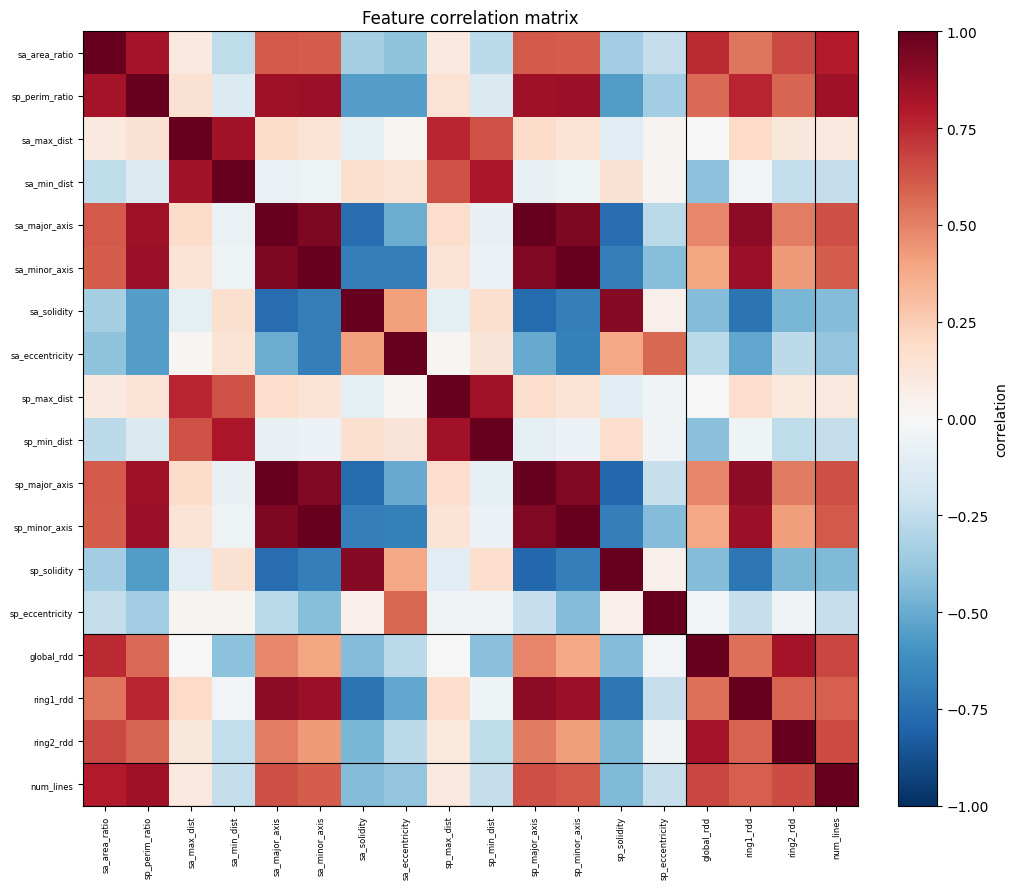

In [51]:
corr_matrix = df_labeled[feature_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")

ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=6)
ax.set_yticklabels(feature_cols, fontsize=6)

group_sizes = [len(regional_cols), len(stat_cols), 1, len(radon_cols)]
boundaries = np.cumsum(group_sizes)[:-1] - 0.5
for b in boundaries:
    ax.axhline(b, color="black", linewidth=0.8)
    ax.axvline(b, color="black", linewidth=0.8)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="correlation")
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

### Training

In [52]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

#### Dataset split

In [53]:
TEST_SIZE = 0.2
N_SPLITS = 5

FEATURE_SET = f"Wu_features"

df_train_val, df_test = train_test_split(
    df_labeled,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=df_labeled["failureType"]
)

X_train_val = df_train_val[feature_cols].copy()
y_train_val = df_train_val["failureType"].copy()
X_test = df_test[feature_cols].copy()
y_test = df_test["failureType"].copy()

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

le = LabelEncoder()
y_train_val_enc = le.fit_transform(y_train_val)

model_results = []

print("Train+Val:", X_train_val.shape)
print("Test:", X_test.shape)
print("Feature set:", FEATURE_SET)

Train+Val: (138360, 18)
Test: (34590, 18)
Feature set: Wu_features


#### Logistic Regression

In [54]:
lr_model = Pipeline([
    ("normalize_features", StandardScaler()),
    ("log_reg_model", LogisticRegression(max_iter=2000, random_state=42))
])
lr_cv_scores = cross_val_score(lr_model, X_train_val, y_train_val, cv=skf, scoring="f1_macro", n_jobs=-1)
print(f"CV macro F1: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")

lr_model.fit(X_train_val, y_train_val)

CV macro F1: 0.7827 ± 0.0035


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('normalize_features', ...), ('log_reg_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some p

#### Random Forest

In [55]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_cv_scores = cross_val_score(rf_model, X_train_val, y_train_val, cv=skf, scoring="f1_macro", n_jobs=-1)
print(f"CV macro F1: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

rf_model.fit(X_train_val, y_train_val)

feat_imp = pd.Series(rf_model.feature_importances_, index=X_train_val.columns)
print(feat_imp.sort_values(ascending=False).head(20))

CV macro F1: 0.8524 ± 0.0042
sp_perim_ratio     0.149481
sa_area_ratio      0.123626
sp_major_axis      0.099636
sa_major_axis      0.081776
sp_solidity        0.066451
sa_solidity        0.062178
ring1_rdd          0.055367
sa_min_dist        0.049823
global_rdd         0.048310
sp_minor_axis      0.047055
sa_minor_axis      0.043191
sp_min_dist        0.041592
num_lines          0.026946
sa_max_dist        0.024838
sp_max_dist        0.023509
ring2_rdd          0.023415
sa_eccentricity    0.017265
sp_eccentricity    0.015542
dtype: float64


#### XGBoost

In [56]:
xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=len(classes),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)
xgb_cv_scores = cross_val_score(xgb_base, X_train_val, y_train_val_enc, cv=skf, scoring="f1_macro", n_jobs=-1)
print(f"CV macro F1: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

xgb_base.fit(X_train_val, y_train_val_enc)


class XGBLabelWrapper:
    def __init__(self, model, label_encoder):
        self.model = model
        self.label_encoder = label_encoder

    def predict(self, X):
        preds_enc = self.model.predict(X)
        return self.label_encoder.inverse_transform(preds_enc.astype(int))


xgb_model = XGBLabelWrapper(xgb_base, le)

CV macro F1: 0.8635 ± 0.0069


#### SVM

In [57]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ("normalize_features", StandardScaler()),
    ("svm_model", SVC(kernel="rbf", random_state=42))
])
svm_cv_scores = cross_val_score(svm_model, X_train_val, y_train_val, cv=skf, scoring="f1_macro", n_jobs=-1)
print(f"CV macro F1: {svm_cv_scores.mean():.4f} ± {svm_cv_scores.std():.4f}")

svm_model.fit(X_train_val, y_train_val)

CV macro F1: 0.8396 ± 0.0040


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('normalize_features', ...), ('svm_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


#### Simple Neural Network

In [58]:
from sklearn.neural_network import MLPClassifier

nn_model = Pipeline([
    ("normalize_features", StandardScaler()),
    ("mlp_model", MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=512,
        learning_rate_init=1e-3,
        max_iter=500,
        random_state=42
    ))
])
nn_cv_scores = cross_val_score(nn_model, X_train_val, y_train_val, cv=skf, scoring="f1_macro", n_jobs=-1)
print(f"CV macro F1: {nn_cv_scores.mean():.4f} ± {nn_cv_scores.std():.4f}")

nn_model.fit(X_train_val, y_train_val)

CV macro F1: 0.8562 ± 0.0057


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('normalize_features', ...), ('mlp_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(32,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regulariz

### Evaluation

In [59]:
from sklearn.metrics import classification_report

In [60]:
def get_model_repr(model):
    if hasattr(model, "named_steps"):
        return str(list(model.named_steps.values())[-1])
    if hasattr(model, "model"):
        return str(model.model)
    return str(model)


def evaluate_classical_model(model, name, X, y, classes, cv_scores=None, feature_set=None, batch_size=50, warmup_batches=5):
    # batched inference timing (matches DL harness: warmup + per-batch loop)
    n_warmup = min(warmup_batches, max(1, len(X) // batch_size))
    for i in range(n_warmup):
        _ = model.predict(X[i*batch_size:(i+1)*batch_size])

    t_total = 0.0
    n_total = 0
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size]
        t0 = time.perf_counter()
        _ = model.predict(xb)
        t_total += time.perf_counter() - t0
        n_total += len(xb)

    inference_s = t_total
    inference_per_sample_ms = inference_s / n_total * 1000

    # full-set predict for metrics (separate from timing)
    preds = model.predict(X)

    report = classification_report(
        y, preds,
        labels=classes,
        target_names=classes,
        output_dict=True,
        zero_division=0
    )
    print(f"\nMetrics for {name}:\n")
    print(f"{'Class':<12} {'F1':>10} {'Precision':>12} {'Recall':>10}")
    print("-" * 48)
    for cls in classes:
        print(
            f"{cls:<12} "
            f"{report[cls]['f1-score']:>10.4f} "
            f"{report[cls]['precision']:>12.4f} "
            f"{report[cls]['recall']:>10.4f}"
        )
    print("-" * 48)
    print(
        f"{'macro avg':<12} "
        f"{report['macro avg']['f1-score']:>10.4f} "
        f"{report['macro avg']['precision']:>12.4f} "
        f"{report['macro avg']['recall']:>10.4f}"
    )
    print(
        f"{'weighted avg':<12} "
        f"{report['weighted avg']['f1-score']:>10.4f} "
        f"{report['weighted avg']['precision']:>12.4f} "
        f"{report['weighted avg']['recall']:>10.4f}"
    )
    print(f"\nOverall Accuracy: {report['accuracy']:.4f}")
    if cv_scores is not None:
        print(f"CV macro F1:      {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Inference time:   {inference_s:.3f}s total, {inference_per_sample_ms:.4f}ms/sample (batch_size={batch_size})")

    result = {
        "name": name,
        "feature_set": feature_set,
        "n_features": X.shape[1],
        "cv_mean_f1": float(cv_scores.mean()) if cv_scores is not None else None,
        "cv_std_f1": float(cv_scores.std()) if cv_scores is not None else None,
        "test_accuracy": report["accuracy"],
        "test_macro_f1": report["macro avg"]["f1-score"],
        "test_macro_precision": report["macro avg"]["precision"],
        "test_macro_recall": report["macro avg"]["recall"],
        "test_weighted_f1": report["weighted avg"]["f1-score"],
        "inference_time_s": inference_s,
        "inference_time_per_sample_ms": inference_per_sample_ms,
        "inference_batch_size": batch_size,
        "n_test_samples": len(X),
        "model_params": get_model_repr(model),
    }
    for cls in classes:
        result[f"f1_{cls}"] = report[cls]["f1-score"]
        result[f"precision_{cls}"] = report[cls]["precision"]
        result[f"recall_{cls}"] = report[cls]["recall"]
    return result

#### Logistic Regression

In [61]:
model_results.append(
    evaluate_classical_model(
        lr_model, "Logistic Regression", X_test, y_test, classes,
        cv_scores=lr_cv_scores, feature_set=FEATURE_SET
    )
)


Metrics for Logistic Regression:

Class                F1    Precision     Recall
------------------------------------------------
none             0.9827       0.9717     0.9940
Edge-Ring        0.9845       0.9825     0.9866
Edge-Loc         0.7487       0.8200     0.6888
Center           0.7829       0.8351     0.7369
Loc              0.4711       0.6890     0.3579
Scratch          0.6425       0.7600     0.5565
Random           0.8639       0.8848     0.8439
Donut            0.6789       0.6916     0.6667
Near-full        0.9508       0.9355     0.9667
------------------------------------------------
macro avg        0.7896       0.8411     0.7553
weighted avg     0.9563       0.9556     0.9600

Overall Accuracy: 0.9600
CV macro F1:      0.7827 ± 0.0035
Inference time:   0.191s total, 0.0055ms/sample (batch_size=50)


#### Random Forest

In [62]:
model_results.append(
    evaluate_classical_model(
        rf_model, "Random Forest", X_test, y_test, classes,
        cv_scores=rf_cv_scores, feature_set=FEATURE_SET
    )
)


Metrics for Random Forest:

Class                F1    Precision     Recall
------------------------------------------------
none             0.9885       0.9811     0.9960
Edge-Ring        0.9835       0.9830     0.9840
Edge-Loc         0.8064       0.8410     0.7746
Center           0.8959       0.9388     0.8568
Loc              0.6785       0.8104     0.5836
Scratch          0.7689       0.9186     0.6611
Random           0.8855       0.9245     0.8497
Donut            0.7429       0.7879     0.7027
Near-full        0.9836       0.9677     1.0000
------------------------------------------------
macro avg        0.8593       0.9059     0.8232
weighted avg     0.9712       0.9711     0.9727

Overall Accuracy: 0.9727
CV macro F1:      0.8524 ± 0.0042
Inference time:   9.422s total, 0.2724ms/sample (batch_size=50)


#### XGBoost

In [63]:
model_results.append(
    evaluate_classical_model(
        xgb_model, "XGBoost", X_test, y_test, classes,
        cv_scores=xgb_cv_scores, feature_set=FEATURE_SET
    )
)


Metrics for XGBoost:

Class                F1    Precision     Recall
------------------------------------------------
none             0.9897       0.9850     0.9943
Edge-Ring        0.9843       0.9815     0.9871
Edge-Loc         0.8213       0.8399     0.8035
Center           0.8964       0.9288     0.8661
Loc              0.7068       0.7924     0.6379
Scratch          0.7919       0.8510     0.7406
Random           0.8850       0.9036     0.8671
Donut            0.7736       0.8119     0.7387
Near-full        0.9180       0.9032     0.9333
------------------------------------------------
macro avg        0.8630       0.8886     0.8410
weighted avg     0.9735       0.9731     0.9744

Overall Accuracy: 0.9744
CV macro F1:      0.8635 ± 0.0069
Inference time:   1.172s total, 0.0339ms/sample (batch_size=50)


#### SVM

In [64]:
model_results.append(
    evaluate_classical_model(
        svm_model, "Support Vector Machine", X_test, y_test, classes,
        cv_scores=svm_cv_scores, feature_set=FEATURE_SET
    )
)


Metrics for Support Vector Machine:

Class                F1    Precision     Recall
------------------------------------------------
none             0.9874       0.9785     0.9966
Edge-Ring        0.9858       0.9826     0.9892
Edge-Loc         0.7969       0.8621     0.7408
Center           0.8609       0.9274     0.8033
Loc              0.6667       0.8268     0.5585
Scratch          0.7451       0.8994     0.6360
Random           0.8832       0.8708     0.8960
Donut            0.7265       0.7232     0.7297
Near-full        0.9492       0.9655     0.9333
------------------------------------------------
macro avg        0.8446       0.8929     0.8093
weighted avg     0.9688       0.9689     0.9707

Overall Accuracy: 0.9707
CV macro F1:      0.8396 ± 0.0040
Inference time:   13.432s total, 0.3883ms/sample (batch_size=50)


#### Simple neural Network

In [65]:
model_results.append(
    evaluate_classical_model(
        nn_model, "Neural Network", X_test, y_test, classes,
        cv_scores=nn_cv_scores, feature_set=FEATURE_SET
    )
)


Metrics for Neural Network:

Class                F1    Precision     Recall
------------------------------------------------
none             0.9893       0.9854     0.9932
Edge-Ring        0.9861       0.9826     0.9897
Edge-Loc         0.8180       0.8289     0.8073
Center           0.8828       0.9027     0.8638
Loc              0.7020       0.7979     0.6267
Scratch          0.7699       0.8169     0.7280
Random           0.8855       0.9245     0.8497
Donut            0.7554       0.7213     0.7928
Near-full        0.9508       0.9355     0.9667
------------------------------------------------
macro avg        0.8600       0.8773     0.8464
weighted avg     0.9725       0.9723     0.9734

Overall Accuracy: 0.9734
CV macro F1:      0.8562 ± 0.0057
Inference time:   0.226s total, 0.0065ms/sample (batch_size=50)


In [66]:
results_df = pd.DataFrame(model_results).sort_values("test_macro_f1", ascending=False)
results_df.to_csv(f"checkpoints/classical_results_{FEATURE_SET}.csv", index=False)

print(results_df[["name", "n_features", "cv_mean_f1", "cv_std_f1", "test_macro_f1", "test_accuracy"]].to_string(index=False))

                  name  n_features  cv_mean_f1  cv_std_f1  test_macro_f1  test_accuracy
               XGBoost          18    0.863462   0.006919       0.862990       0.974357
        Neural Network          18    0.856196   0.005692       0.859981       0.973374
         Random Forest          18    0.852439   0.004193       0.859305       0.972709
Support Vector Machine          18    0.839580   0.003955       0.844624       0.970685
   Logistic Regression          18    0.782747   0.003522       0.789571       0.960017


In [67]:
timing_df = (
    pd.DataFrame(model_results)
    [["name", "n_features", "test_macro_f1", "inference_time_s", "inference_time_per_sample_ms", "n_test_samples"]]
    .sort_values("inference_time_per_sample_ms")
    .round(6)
)
print(timing_df.to_string(index=False))

                  name  n_features  test_macro_f1  inference_time_s  inference_time_per_sample_ms  n_test_samples
   Logistic Regression          18       0.789571          0.190662                      0.005512           34590
        Neural Network          18       0.859981          0.226129                      0.006537           34590
               XGBoost          18       0.862990          1.172228                      0.033889           34590
         Random Forest          18       0.859305          9.422117                      0.272394           34590
Support Vector Machine          18       0.844624         13.432148                      0.388325           34590
